**DeepSort的代码执行流程：**
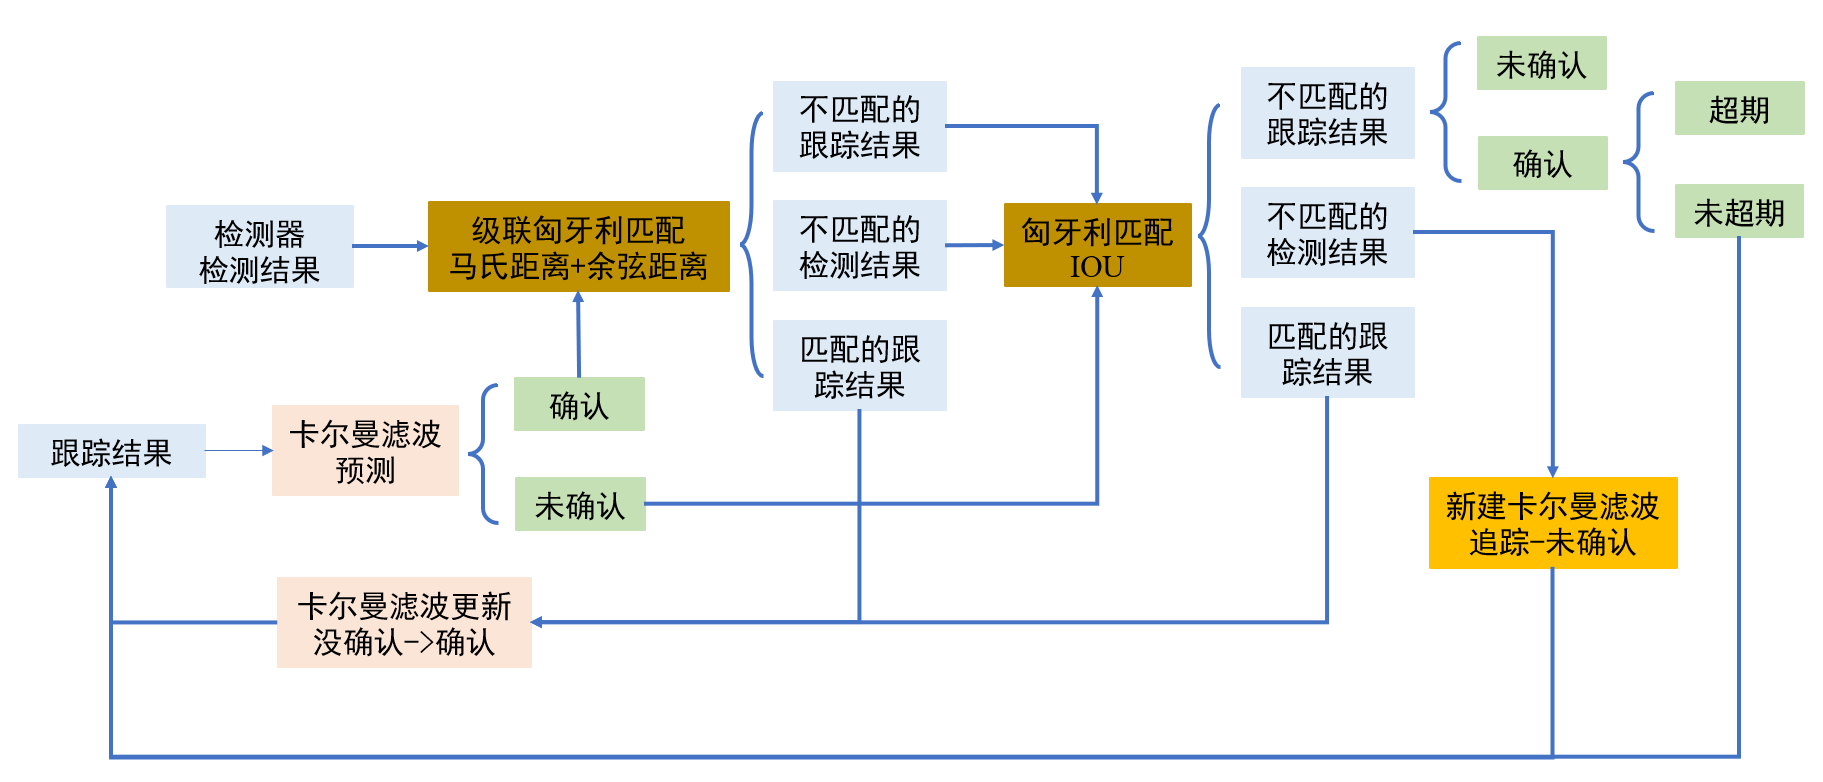

In [1]:
#导入一些需要用到的库
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import torch
import cv2
import numpy as np
from torchvision import models
from tqdm import tqdm

import scipy.linalg
from scipy.optimize import linear_sum_assignment as linear_assignment  #匈牙利算法实现

In [2]:
#实现了一个卡尔曼滤波器，状态变量为（x,y,aspect,h,xv,yv,aspectv,hv），观测量就是目标框的位置和大小（x,y,aspect,h）
class KalmanFilter(object):
    def __init__(self):
        ndim, dt = 4, 1.
        self._motion_mat = np.eye(2 * ndim, 2 * ndim)
        for i in range(ndim):
            self._motion_mat[i, ndim + i] = dt
            
        self._update_mat = np.eye(ndim, 2 * ndim)

        self._std_weight_position = 1. / 20
        self._std_weight_velocity = 1. / 160

    def initiate(self, measurement):
        mean_pos = measurement
        mean_vel = np.zeros_like(mean_pos)
        mean = np.r_[mean_pos, mean_vel]

        std = [
            2 * self._std_weight_position * measurement[3],
            2 * self._std_weight_position * measurement[3],
            1e-2,
            2 * self._std_weight_position * measurement[3],
            10 * self._std_weight_velocity * measurement[3],
            10 * self._std_weight_velocity * measurement[3],
            1e-5,
            10 * self._std_weight_velocity * measurement[3]]
        covariance = np.diag(np.square(std))
        return mean, covariance

    def predict(self, mean, covariance):
        std_pos = [
            self._std_weight_position * mean[3],
            self._std_weight_position * mean[3],
            1e-2,
            self._std_weight_position * mean[3]]
        std_vel = [
            self._std_weight_velocity * mean[3],
            self._std_weight_velocity * mean[3],
            1e-5,
            self._std_weight_velocity * mean[3]]
        motion_cov = np.diag(np.square(np.r_[std_pos, std_vel]))

        mean = np.dot(self._motion_mat, mean)
        covariance = np.linalg.multi_dot((
            self._motion_mat, covariance, self._motion_mat.T)) + motion_cov

        return mean, covariance

    def project(self, mean, covariance):
        std = [
            self._std_weight_position * mean[3],
            self._std_weight_position * mean[3],
            1e-1,
            self._std_weight_position * mean[3]]
        innovation_cov = np.diag(np.square(std))

        mean = np.dot(self._update_mat, mean)
        covariance = np.linalg.multi_dot((
            self._update_mat, covariance, self._update_mat.T))
        return mean, covariance + innovation_cov

    def update(self, mean, covariance, measurement):
        projected_mean, projected_cov = self.project(mean, covariance)

        chol_factor, lower = scipy.linalg.cho_factor(
            projected_cov, lower=True, check_finite=False)
        kalman_gain = scipy.linalg.cho_solve(
            (chol_factor, lower), np.dot(covariance, self._update_mat.T).T,
            check_finite=False).T
        innovation = measurement - projected_mean

        new_mean = mean + np.dot(innovation, kalman_gain.T)
        new_covariance = covariance - np.linalg.multi_dot((
            kalman_gain, projected_cov, kalman_gain.T))
        return new_mean, new_covariance

    def gating_distance(self, mean, covariance, measurements,only_position=False):
        mean, covariance = self.project(mean, covariance)
        if only_position:
            mean, covariance = mean[:2], covariance[:2, :2]
            measurements = measurements[:, :2]

        cholesky_factor = np.linalg.cholesky(covariance)
        d = measurements - mean
        z = scipy.linalg.solve_triangular(
            cholesky_factor, d.T, lower=True, check_finite=False,
            overwrite_b=True)
        squared_maha = np.sum(z * z, axis=0)
        return squared_maha

In [3]:
#根据目标特征来计算欧氏距离
def _pdist(a, b):
    #Compute pair-wise squared distance between points in `a` and `b`.
    a, b = np.asarray(a), np.asarray(b)
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    a2, b2 = np.square(a).sum(axis=1), np.square(b).sum(axis=1)
    r2 = -2. * np.dot(a, b.T) + a2[:, None] + b2[None, :]
    r2 = np.clip(r2, 0., float(np.inf))
    return r2

def _nn_euclidean_distance(x, y):
    distances = _pdist(x, y)
    return np.maximum(0.0, distances.min(axis=0))

#根据目标特征来计算余弦距离
def _cosine_distance(a, b, data_is_normalized=False):
    #Compute pair-wise cosine distance between points in `a` and `b`.
    if not data_is_normalized:
        a = np.asarray(a) / np.linalg.norm(a, axis=1, keepdims=True)
        b = np.asarray(b) / np.linalg.norm(b, axis=1, keepdims=True)
    return 1. - np.dot(a, b.T)


def _nn_cosine_distance(x, y):
    distances = _cosine_distance(x, y)
    return distances.min(axis=0)


#计算代价矩阵
class NearestNeighborDistanceMetric(object):

    def __init__(self, metric, matching_threshold, budget=None):
        if metric == "euclidean":
            self._metric = _nn_euclidean_distance
        elif metric == "cosine":
            self._metric = _nn_cosine_distance
        else:
            raise ValueError(
                "Invalid metric; must be either 'euclidean' or 'cosine'")
        self.matching_threshold = matching_threshold
        self.budget = budget
        self.samples = {}

    def partial_fit(self, features, targets, active_targets):
        for feature, target in zip(features, targets):
            self.samples.setdefault(target, []).append(feature)
            if self.budget is not None:
                self.samples[target] = self.samples[target][-self.budget:]
        self.samples = {k: self.samples[k] for k in active_targets}

    def distance(self, features, targets):
        cost_matrix = np.zeros((len(targets), len(features)))
        for i, target in enumerate(targets):
            cost_matrix[i, :] = self._metric(self.samples[target], features)
        return cost_matrix

In [4]:
#上限代价门槛常量
INFTY_COST = 1e+5

#匈牙利匹配
def min_cost_matching(distance_metric, max_distance, tracks, detections, track_indices=None, detection_indices=None):

    if track_indices is None:
        track_indices = np.arange(len(tracks))
    if detection_indices is None:
        detection_indices = np.arange(len(detections))

    if len(detection_indices) == 0 or len(track_indices) == 0:
        return [], track_indices, detection_indices  # Nothing to match.

    cost_matrix = distance_metric(tracks, detections, track_indices, detection_indices)
    cost_matrix[cost_matrix > max_distance] = max_distance + 1e-5
    indices = linear_assignment(cost_matrix)
    indices_row = list(indices[0])
    indices_col = list(indices[1])
    indices = zip(indices[0],indices[1])

    matches, unmatched_tracks, unmatched_detections = [], [], []
    for col, detection_idx in enumerate(detection_indices):
        if col not in indices_col:
            unmatched_detections.append(detection_idx)
    for row, track_idx in enumerate(track_indices):
        if row not in indices_row:
            unmatched_tracks.append(track_idx)
    for row, col in indices:
        track_idx = track_indices[row]
        detection_idx = detection_indices[col]
        if cost_matrix[row, col] > max_distance:
            unmatched_tracks.append(track_idx)
            unmatched_detections.append(detection_idx)
        else:
            matches.append((track_idx, detection_idx))
    return matches, unmatched_tracks, unmatched_detections

#级联匹配
def matching_cascade(
        distance_metric, max_distance, cascade_depth, tracks, detections,
        track_indices=None, detection_indices=None):
    if track_indices is None:
        track_indices = list(range(len(tracks)))
    if detection_indices is None:
        detection_indices = list(range(len(detections)))

    unmatched_detections = detection_indices
    matches = []
    for level in range(cascade_depth):
        if len(unmatched_detections) == 0:  # No detections left
            break

        track_indices_l = [
            k for k in track_indices
            if tracks[k].time_since_update == 1 + level
        ]
        if len(track_indices_l) == 0:  # Nothing to match at this level
            continue

        matches_l, _, unmatched_detections = min_cost_matching(
                distance_metric, max_distance, tracks, detections,
                track_indices_l, unmatched_detections)
        matches += matches_l
    unmatched_tracks = list(set(track_indices) - set(k for k, _ in matches))
    return matches, unmatched_tracks, unmatched_detections

#根据马氏距离来调整代价矩阵

chi2inv95 = {
    1: 3.8415,
    2: 5.9915,
    3: 7.8147,
    4: 9.4877,
    5: 11.070,
    6: 12.592,
    7: 14.067,
    8: 15.507,
    9: 16.919}

def gate_cost_matrix(
        kf, cost_matrix, tracks, detections, track_indices, detection_indices, gated_cost=INFTY_COST, only_position=False):
    gating_dim = 2 if only_position else 4
    gating_threshold = chi2inv95[gating_dim]
    measurements = np.asarray(
        [detections[i].to_xyah() for i in detection_indices])
    for row, track_idx in enumerate(track_indices):
        track = tracks[track_idx]
        gating_distance = kf.gating_distance(
            track.mean, track.covariance, measurements, only_position)
        cost_matrix[row, gating_distance > gating_threshold] = gated_cost
    return cost_matrix


#计算IOU
def iou(bbox, candidates):
    bbox_tl, bbox_br = bbox[:2], bbox[:2] + bbox[2:]
    candidates_tl = candidates[:, :2]
    candidates_br = candidates[:, :2] + candidates[:, 2:]

    tl = np.c_[np.maximum(bbox_tl[0], candidates_tl[:, 0])[:, np.newaxis],
               np.maximum(bbox_tl[1], candidates_tl[:, 1])[:, np.newaxis]]
    br = np.c_[np.minimum(bbox_br[0], candidates_br[:, 0])[:, np.newaxis],
               np.minimum(bbox_br[1], candidates_br[:, 1])[:, np.newaxis]]
    wh = np.maximum(0., br - tl)

    area_intersection = wh.prod(axis=1)
    area_bbox = bbox[2:].prod()
    area_candidates = candidates[:, 2:].prod(axis=1)
    return area_intersection / (area_bbox + area_candidates - area_intersection)


#计算IOU代价矩阵
def iou_cost(tracks, detections, track_indices=None, detection_indices=None):
    if track_indices is None:
        track_indices = np.arange(len(tracks))
    if detection_indices is None:
        detection_indices = np.arange(len(detections))

    cost_matrix = np.zeros((len(track_indices), len(detection_indices)))
    for row, track_idx in enumerate(track_indices):
        if tracks[track_idx].time_since_update > 1:
            cost_matrix[row, :] = INFTY_COST
            continue

        bbox = tracks[track_idx].to_tlwh()
        candidates = np.asarray([detections[i].tlwh for i in detection_indices])
        cost_matrix[row, :] = 1. - iou(bbox, candidates)
    return cost_matrix


In [5]:
#一个目标框的追踪器的实现，包含了跟踪过程中需要的信息
class Track:
    #追踪器的三种状态
    Tentative = 1
    Confirmed = 2
    Deleted = 3

    def __init__(self, mean, covariance, track_id, n_init, max_age,feature=None):
        self.mean = mean
        self.covariance = covariance
        self.track_id = track_id
        self.hits = 1
        self.age = 1
        self.time_since_update = 0

        self.state = Track.Tentative
        self.features = []
        if feature is not None:
            self.features.append(feature)

        self._n_init = n_init
        self._max_age = max_age

    def to_tlwh(self):
        ret = self.mean[:4].copy()
        ret[2] *= ret[3]
        ret[:2] -= ret[2:] / 2
        return ret

    def to_tlbr(self):
        ret = self.to_tlwh()
        ret[2:] = ret[:2] + ret[2:]
        return ret

    def predict(self, kf):
        self.mean, self.covariance = kf.predict(self.mean, self.covariance)
        self.age += 1
        self.time_since_update += 1

    def update(self, kf, detection):
        self.mean, self.covariance = kf.update(
            self.mean, self.covariance, detection.to_xyah())
        self.features.append(detection.feature)

        self.hits += 1
        self.time_since_update = 0
        if self.state == Track.Tentative and self.hits >= self._n_init:
            self.state = Track.Confirmed

    def mark_missed(self):
        if self.state == Track.Tentative:
            self.state = Track.Deleted
        elif self.time_since_update > self._max_age:
            self.state = Track.Deleted

    def is_tentative(self):
        return self.state == Track.Tentative

    def is_confirmed(self):
        return self.state == Track.Confirmed

    def is_deleted(self):
        return self.state == Track.Deleted

In [6]:
#总的多目标追踪管理器，根据目标检测的结果，匹配跟踪的目标，添加新出现的目标，删除不存在的目标
class Tracker:
    def __init__(self, metric, max_iou_distance=0.7, max_age=30, n_init=3):
        self.metric = metric
        self.max_iou_distance = max_iou_distance
        self.max_age = max_age
        self.n_init = n_init

        self.kf = KalmanFilter()
        self.tracks = []
        self._next_id = 1

    def predict(self):
        for track in self.tracks:
            track.predict(self.kf)

    def update(self, detections):
        # Run matching cascade.
        matches, unmatched_tracks, unmatched_detections = self._match(detections)

        # Update track set.
        for track_idx, detection_idx in matches:
            self.tracks[track_idx].update(self.kf, detections[detection_idx])
        for track_idx in unmatched_tracks:
            self.tracks[track_idx].mark_missed()
        for detection_idx in unmatched_detections:
            self._initiate_track(detections[detection_idx])
            
        self.tracks = [t for t in self.tracks if not t.is_deleted()]

        # Update distance metric.
        active_targets = [t.track_id for t in self.tracks if t.is_confirmed()]
        features, targets = [], []
        for track in self.tracks:
            if not track.is_confirmed():
                continue
            features += track.features
            targets += [track.track_id for _ in track.features]
            track.features = []
        self.metric.partial_fit(
            np.asarray(features), np.asarray(targets), active_targets)

    def _match(self, detections):

        def gated_metric(tracks, dets, track_indices, detection_indices):
            features = np.array([dets[i].feature for i in detection_indices])
            targets = np.array([tracks[i].track_id for i in track_indices])
            cost_matrix = self.metric.distance(features, targets)
            cost_matrix = gate_cost_matrix(
                self.kf, cost_matrix, tracks, dets, track_indices,
                detection_indices)

            return cost_matrix

        # Split track set into confirmed and unconfirmed tracks.
        confirmed_tracks = [i for i, t in enumerate(self.tracks) if t.is_confirmed()]
        unconfirmed_tracks = [i for i, t in enumerate(self.tracks) if not t.is_confirmed()]

        # Associate confirmed tracks using appearance features.
        matches_a, unmatched_tracks_a, unmatched_detections = matching_cascade(
                gated_metric, self.metric.matching_threshold, self.max_age,
                self.tracks, detections, confirmed_tracks)

        # Associate remaining tracks together with unconfirmed tracks using IOU.
        iou_track_candidates = unconfirmed_tracks + [k for k in unmatched_tracks_a if self.tracks[k].time_since_update == 1]
        unmatched_tracks_a = [k for k in unmatched_tracks_a if self.tracks[k].time_since_update != 1]
        matches_b, unmatched_tracks_b, unmatched_detections = min_cost_matching(
                iou_cost, self.max_iou_distance, self.tracks,
                detections, iou_track_candidates, unmatched_detections)

        matches = matches_a + matches_b
        unmatched_tracks = list(set(unmatched_tracks_a + unmatched_tracks_b))
        return matches, unmatched_tracks, unmatched_detections

    def _initiate_track(self, detection):
        mean, covariance = self.kf.initiate(detection.to_xyah())
        self.tracks.append(Track(
            mean, covariance, self._next_id, self.n_init, self.max_age,
            detection.feature))
        self._next_id += 1

In [7]:
#目标特征提取类，提取各个目标框内目标的语义特征
class Extractor(object):
    def __init__(self, net):
        self.net = net
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.net.to(self.device)

    def __call__(self, img):
        assert isinstance(img, np.ndarray), "type error"
        img = cv2.resize(img, (64,128))/255.0
        img = torch.as_tensor(img, dtype=torch.float32, device=self.device).permute(2,0,1)[None,...]
        with torch.no_grad():
            feature = self.net(img)
            feature = torch.flatten(feature)
        return feature.cpu().numpy()
    
    
#检测结果类，用于包装检测器检测到的结果和提取的特征
class Detection(object):
    def __init__(self, tlwh, confidence, feature):
        self.tlwh = np.asarray(tlwh, dtype=np.float32)
        self.confidence = float(confidence)
        self.feature = np.asarray(feature, dtype=np.float32)

    def to_tlbr(self): #(xmin,ymin,w,h)-->(xmin,ymin,xmax,ymax)
        ret = self.tlwh.copy()
        ret[2:] += ret[:2]
        return ret

    def to_xyah(self): #(xmin,ymin,w,h)-->(center x, center y,aspect,h)
        ret = self.tlwh.copy()
        ret[:2] += ret[2:] / 2
        ret[2] /= ret[3]
        return ret
    
#目标检测类，用于检测每一帧图像里的目标，并且用Extractor提取每个目标区域的语义特征
class Detector(object):
    def __init__(self, detector_net, extractor_net, classes=(1,3)): #(1:person, 3:car)
        self.detector_net = detector_net
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.detector_net.to(self.device)
        self.extractor = Extractor(extractor_net)
        self.classes = classes
        
    def detect(self,img):
        assert isinstance(img, np.ndarray), "type error"
        img_t = torch.from_numpy(img)/255.0
        img_t = img_t.permute(2,0,1)[None,...]
        img_t = img_t.to(self.device)
        with torch.no_grad():      
            results = self.detector_net(img_t)
            boxes = results[0]['boxes'].cpu().numpy().astype(np.int32)
            labels = results[0]['labels']
            scores = results[0]['scores']
        detections = []
        for index, label in enumerate(labels):
            if label in self.classes:
                box = boxes[index]
                score = scores[index].item()
                feature = self.extractor(img[box[1]:box[3],box[0]:box[2]])
                box[2:] -= box[:2]
                detections.append(Detection(box,score,feature))
                
        return detections

In [8]:
#初始化追踪器
metric = NearestNeighborDistanceMetric("euclidean", matching_threshold=100)
tracker = Tracker(metric)

#简单的测试,可以采用torchvison提供的resnet和fasterrcnn 作为特征提取器和目标检测器
#初始化检测器和特征提取器
resnet18 = models.resnet18(pretrained=True)
resnet18.fc = torch.nn.Identity()
resnet18.eval()

fasterrcnn = models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=True,\
                                 box_score_thresh=0.9,\
                                 box_nms_thresh=0.7)

fasterrcnn.eval()
detector = Detector(fasterrcnn, resnet18)

#需要测试的视频文件路径和视频信息
video_path = "/kaggle/input/mot16-test/MOT16-07-raw.mp4"
video = cv2.VideoCapture(video_path)
frame_width = int(video.get(3))
frame_height = int(video.get(4))
fps = video.get(5)
frame_count = int(video.get(7))
#输出视频信息
out_path = "output.avi"
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(out_path, fourcc, fps, (frame_width,frame_height))

with tqdm(total=frame_count) as pbar:
    pbar.set_description('Processing:')
    while(True):
        try:
            ret, frame = video.read()
            if not ret: break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            detections = detector.detect(frame)
            tracker.predict()
            tracker.update(detections)
            for track in tracker.tracks:
                box = track.to_tlbr().astype(np.int32)
                cv2.rectangle(frame, (box[0], box[1]), (box[2], box[3]), (255,0,0), 2)
                cv2.putText(frame,str(track.track_id),((box[0]+box[2])//2, box[1]+20),cv2.FONT_HERSHEY_COMPLEX,0.8,(0,0,255),2)

            out.write(frame)
            pbar.update(1)
        except KeyboardInterrupt:
            break

    video.release()
    out.release()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


  0%|          | 0.00/74.2M [00:00<?, ?B/s]

Processing:: 100%|██████████| 500/500 [01:02<00:00,  7.94it/s]


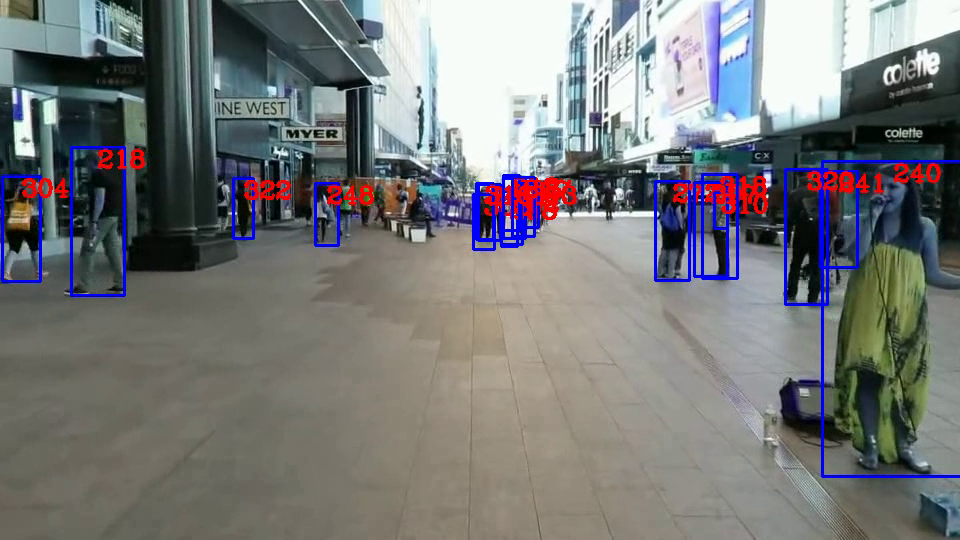

In [9]:
from IPython.display import clear_output, display
from PIL import Image

video = cv2.VideoCapture(out_path)
while(True):
    try:
        clear_output(wait=True)
        ret, frame = video.read()
        if not ret: break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(frame)
        display(img)
    except KeyboardInterrupt: break
        
video.release()